Number of regressors in the base model: 11
Number of regressors in the polynomial model: 27
Number of regressors in the interacted model: 352
Test R2 for the basic model: 0.193438585474084
Test R2 for the polynomial model: 0.24045444747831812
Test R2 for the interacted model: -35.133950102278995
R-squared for the basic model: 0.2388475733534342
adjusted R-squared for the basic model: 0.2378948227880987
R-squared for the polynomial model: 0.3087135315825986
adjusted R-squared for the polynomial model: 0.3064592423340281
R-squared for the interacted model: 0.48391322383982704
adjusted R-squared for the interacted model: 0.4602277559485848

R-squared Comparison Table:
            R²_test  R²_sample  R²_adjusted
basic         0.193      0.239        0.238
polynomial    0.240      0.309        0.306
interacted  -35.134      0.484        0.460


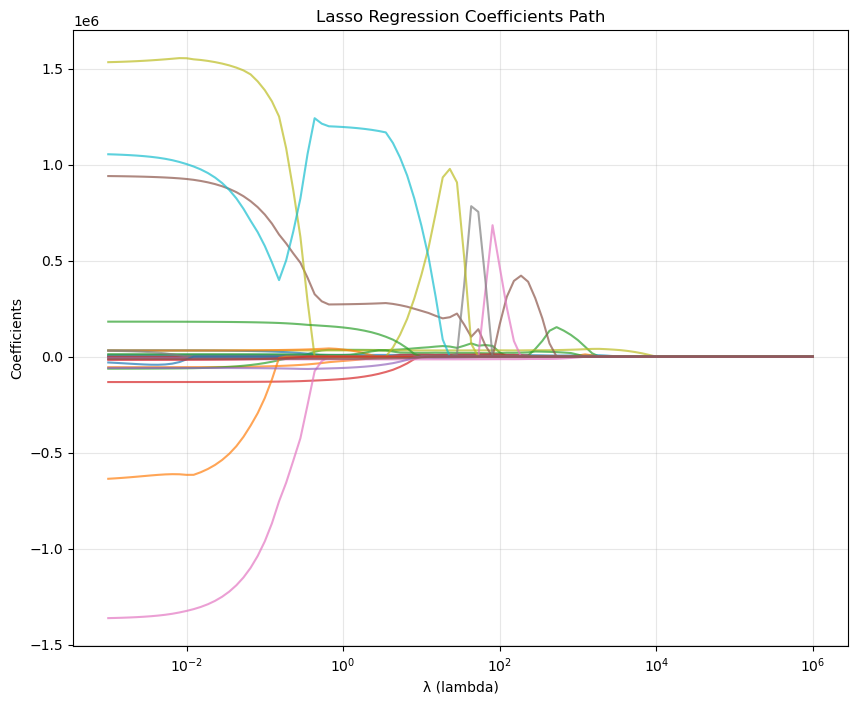


Cross-Validation RMSE Table:
          Base  Polynomial  Interactions
OLS    56135.0    110827.0   745358799.0
Lasso  56135.0     53895.0       51936.0



Final Performance Table (R²):
                  Base  Polynomial  Interactions
OLS - average    0.193       0.239       -49.312
OLS - refit      0.193       0.240       -35.134
Lasso - average  0.194       0.238         0.196
Lasso - refit    0.194       0.238         0.195


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations_with_replacement
import warnings
warnings.filterwarnings('ignore')

# Read in 401k data
data401k = pd.read_csv("../Data/restatw.dat", sep=r'\s+')  # Read in 401k data

# Variables we care about are:
# net total financial assets (net_tfa)
# 401(k) participation (p401)
# 401(k) eligibility (e401)
# income (inc)
# age (age)
# family size (fsize)
# years schooling (educ)
# marital status (marr)
# gender (male)
# two-earner household (twoearn)

# Normalize inc, age, fsize, educ
data401k['age'] = data401k['age'] / 64
data401k['inc'] = data401k['inc'] / 250000
data401k['fsize'] = data401k['fsize'] / 13
data401k['educ'] = data401k['educ'] / 18

#########################################
# Set up training and testing sample
#########################################
np.random.seed(8261977)
ntrain = 8000  # number of training observations
n_total = len(data401k)
tr_indices = np.random.choice(n_total, ntrain, replace=False)  # draw ntrain observations from original data
train = data401k.iloc[tr_indices].copy()  # Training sample
test = data401k.iloc[~data401k.index.isin(tr_indices)].copy()  # Testing sample
nTr = len(train)
nTe = len(test)

##########################################
# Some model specifications
##########################################

# Base model features
base_features = ['e401', 'age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']

# Create polynomial features for polynomial model
def create_poly_features(df, features_config):
    """Create polynomial features based on configuration"""
    result_df = df.copy()

    for feature, degree in features_config.items():
        if degree > 1:
            for d in range(2, degree + 1):
                result_df[f'{feature}_poly_{d}'] = df[feature] ** d

    return result_df

# Polynomial model configuration
poly_config = {
    'age': 6,
    'inc': 8,
    'educ': 4,
    'fsize': 2
}

# Create polynomial features
train_poly = create_poly_features(train, poly_config)
test_poly = create_poly_features(test, poly_config)

# Define feature sets
poly_features = base_features.copy()
for feature, degree in poly_config.items():
    for d in range(2, degree + 1):
        poly_features.append(f'{feature}_poly_{d}')

# Create interaction features
def create_interaction_features(df, base_features, poly_features):
    """Create all pairwise interactions between features"""
    result_df = df.copy()

    # Get all features to interact
    all_features = poly_features.copy()

    # Create all pairwise interactions
    for i, feat1 in enumerate(all_features):
        for j, feat2 in enumerate(all_features[i:], i):
            if i != j:  # Don't interact feature with itself
                interaction_name = f'{feat1}_x_{feat2}'
                result_df[interaction_name] = df[feat1] * df[feat2]

    return result_df

# Create interaction features
train_int = create_interaction_features(train_poly, base_features, poly_features)
test_int = create_interaction_features(test_poly, base_features, poly_features)

# Get interaction feature names
int_features = poly_features.copy()
for i, feat1 in enumerate(poly_features):
    for j, feat2 in enumerate(poly_features[i:], i):
        if i != j:
            int_features.append(f'{feat1}_x_{feat2}')

################################################
# Baseline OLS results
################################################

# Prepare feature matrices
X_train_base = train[base_features]
X_test_base = test[base_features]
X_train_poly = train_poly[poly_features]
X_test_poly = test_poly[poly_features]
X_train_int = train_int[int_features]
X_test_int = test_int[int_features]

y_train = train['net_tfa']
y_test = test['net_tfa']

# Estimate models in training data
reg_base = LinearRegression()
reg_base.fit(X_train_base, y_train)
print(f"Number of regressors in the base model: {len(base_features) + 1}")  # +1 for intercept

reg_poly = LinearRegression()
reg_poly.fit(X_train_poly, y_train)
print(f"Number of regressors in the polynomial model: {len(poly_features) + 1}")  # +1 for intercept

reg_int = LinearRegression()
reg_int.fit(X_train_int, y_train)
print(f"Number of regressors in the interacted model: {len(int_features) + 1}")  # +1 for intercept

# Calculate the out-of-sample MSE and R^2
fit_reg_base = reg_base.predict(X_test_base)
fit_reg_poly = reg_poly.predict(X_test_poly)
fit_reg_int = reg_int.predict(X_test_int)

MSE_test1 = mean_squared_error(y_test, fit_reg_base)
R2_test1 = 1 - MSE_test1 / (np.sum((y_test - np.mean(y_train))**2) / len(y_test))

MSE_test2 = mean_squared_error(y_test, fit_reg_poly)
R2_test2 = 1 - MSE_test2 / (np.sum((y_test - np.mean(y_train))**2) / len(y_test))

MSE_test3 = mean_squared_error(y_test, fit_reg_int)
R2_test3 = 1 - MSE_test3 / (np.sum((y_test - np.mean(y_train))**2) / len(y_test))

print(f"Test R2 for the basic model: {R2_test1}")
print(f"Test R2 for the polynomial model: {R2_test2}")
print(f"Test R2 for the interacted model: {R2_test3}")

# In-sample MSE and R^2
R2V_1 = reg_base.score(X_train_base, y_train)
print(f"R-squared for the basic model: {R2V_1}")

# Calculate adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

R2V_adj1 = adjusted_r2(R2V_1, len(y_train), len(base_features))
print(f"adjusted R-squared for the basic model: {R2V_adj1}")

R2V_2 = reg_poly.score(X_train_poly, y_train)
print(f"R-squared for the polynomial model: {R2V_2}")

R2V_adj2 = adjusted_r2(R2V_2, len(y_train), len(poly_features))
print(f"adjusted R-squared for the polynomial model: {R2V_adj2}")

R2V_3 = reg_int.score(X_train_int, y_train)
print(f"R-squared for the interacted model: {R2V_3}")

R2V_adj3 = adjusted_r2(R2V_3, len(y_train), len(int_features))
print(f"adjusted R-squared for the interacted model: {R2V_adj3}")

# Output the table
table_data = [
    [R2_test1, R2V_1, R2V_adj1],
    [R2_test2, R2V_2, R2V_adj2],
    [R2_test3, R2V_3, R2V_adj3]
]

table_df = pd.DataFrame(table_data,
                       columns=['R²_test', 'R²_sample', 'R²_adjusted'],
                       index=['basic', 'polynomial', 'interacted'])

print("\nR-squared Comparison Table:")
print(table_df.round(3))

##############################################################
# HDLMs (High Dimensional Linear Models)
##############################################################

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=8261977)
fold_indices = list(kf.split(X_train_base))

# Lasso regression with different lambda values
lasso_lambdas = np.logspace(-3, 6, 100)

lasso_poly = Lasso(max_iter=2000)
lasso_coeffs = []
lasso_scores = []

for alpha in lasso_lambdas:
    lasso_temp = Lasso(alpha=alpha, max_iter=2000)
    lasso_temp.fit(X_train_poly, y_train)
    lasso_coeffs.append(lasso_temp.coef_)
    lasso_scores.append(lasso_temp.score(X_train_poly, y_train))

lasso_coeffs = np.array(lasso_coeffs)

# Plot Lasso coefficients (Spaghetti plot)
plt.figure(figsize=(10, 8))
for i in range(lasso_coeffs.shape[1]):
    plt.plot(lasso_lambdas, lasso_coeffs[:, i], alpha=0.7)
plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('Coefficients')
plt.title('Lasso Regression Coefficients Path')
plt.grid(True, alpha=0.3)
plt.show()

#################################################################
# Cross-validation for penalty parameter choice
#################################################################

# Cross-validation for Lasso
cv_lasso_base = LassoCV(cv=5, random_state=8261977, max_iter=2000)
cv_lasso_base.fit(X_train_base, y_train)

cv_lasso_poly = LassoCV(cv=5, random_state=8261977, max_iter=2000)
cv_lasso_poly.fit(X_train_poly, y_train)

cv_lasso_int = LassoCV(cv=5, random_state=8261977, max_iter=2000)
cv_lasso_int.fit(X_train_int, y_train)

# Calculate CV scores for OLS for comparison
def cv_ols_score(X, y, cv_folds):
    """Calculate cross-validation score for OLS"""
    scores = []
    for train_idx, val_idx in cv_folds:
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        reg = LinearRegression()
        reg.fit(X_train_cv, y_train_cv)
        y_pred = reg.predict(X_val_cv)
        scores.append(mean_squared_error(y_val_cv, y_pred))

    return np.mean(scores)

cv_ols_base_score = cv_ols_score(X_train_base, y_train, fold_indices)
cv_ols_poly_score = cv_ols_score(X_train_poly, y_train, fold_indices)
cv_ols_int_score = cv_ols_score(X_train_int, y_train, fold_indices)

# For Lasso, we need to compute CV scores manually since LassoCV doesn't store them
def get_lasso_cv_score(X, y, alpha, cv_folds):
    scores = []
    for train_idx, val_idx in cv_folds:
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        lasso = Lasso(alpha=alpha, max_iter=2000)
        lasso.fit(X_train_cv, y_train_cv)
        y_pred = lasso.predict(X_val_cv)
        scores.append(mean_squared_error(y_val_cv, y_pred))

    return np.mean(scores)

cv_lasso_base_score = get_lasso_cv_score(X_train_base, y_train, cv_lasso_base.alpha_, fold_indices)
cv_lasso_poly_score = get_lasso_cv_score(X_train_poly, y_train, cv_lasso_poly.alpha_, fold_indices)
cv_lasso_int_score = get_lasso_cv_score(X_train_int, y_train, cv_lasso_int.alpha_, fold_indices)

# Table of CV RMSEs
cv_table_data = [
    [np.sqrt(cv_ols_base_score), np.sqrt(cv_ols_poly_score), np.sqrt(cv_ols_int_score)],
    [np.sqrt(cv_lasso_base_score), np.sqrt(cv_lasso_poly_score), np.sqrt(cv_lasso_int_score)]
]

cv_table_df = pd.DataFrame(cv_table_data,
                          columns=['Base', 'Polynomial', 'Interactions'],
                          index=['OLS', 'Lasso'])

print("\nCross-Validation RMSE Table:")
print(cv_table_df.round(0))

##############################################################
# Performance on validation data
##############################################################

# Prediction rule one - cross-validated fits
def cv_predictions(X_train, y_train, X_test, model_type, cv_folds, alpha=None):
    """Generate cross-validated predictions"""
    predictions = np.zeros((len(X_test), len(cv_folds)))

    for i, (train_idx, val_idx) in enumerate(cv_folds):
        X_train_cv = X_train.iloc[train_idx]
        y_train_cv = y_train.iloc[train_idx]

        if model_type == 'ols':
            model = LinearRegression()
        elif model_type == 'lasso':
            model = Lasso(alpha=alpha, max_iter=2000)

        model.fit(X_train_cv, y_train_cv)
        predictions[:, i] = model.predict(X_test)

    return predictions

# Generate CV predictions for all models
yhat_te_base = cv_predictions(X_train_base, y_train, X_test_base, 'ols', fold_indices)
yhat_te_poly = cv_predictions(X_train_poly, y_train, X_test_poly, 'ols', fold_indices)
yhat_te_int = cv_predictions(X_train_int, y_train, X_test_int, 'ols', fold_indices)

yhat_te_lasso_base = cv_predictions(X_train_base, y_train, X_test_base, 'lasso', fold_indices, cv_lasso_base.alpha_)
yhat_te_lasso_poly = cv_predictions(X_train_poly, y_train, X_test_poly, 'lasso', fold_indices, cv_lasso_poly.alpha_)
yhat_te_lasso_int = cv_predictions(X_train_int, y_train, X_test_int, 'lasso', fold_indices, cv_lasso_int.alpha_)

# Calculate R² for averaged predictions
def r2_from_predictions(y_true, y_pred, y_train_mean):
    mse = mean_squared_error(y_true, y_pred)
    total_variance = np.sum((y_true - y_train_mean)**2) / len(y_true)
    return 1 - mse / total_variance

y_train_mean = np.mean(y_train)

# R² for averaged CV predictions
r2_CVave_ols_base = r2_from_predictions(y_test, np.mean(yhat_te_base, axis=1), y_train_mean)
r2_CVave_ols_poly = r2_from_predictions(y_test, np.mean(yhat_te_poly, axis=1), y_train_mean)
r2_CVave_ols_int = r2_from_predictions(y_test, np.mean(yhat_te_int, axis=1), y_train_mean)

r2_CVave_lasso_base = r2_from_predictions(y_test, np.mean(yhat_te_lasso_base, axis=1), y_train_mean)
r2_CVave_lasso_poly = r2_from_predictions(y_test, np.mean(yhat_te_lasso_poly, axis=1), y_train_mean)
r2_CVave_lasso_int = r2_from_predictions(y_test, np.mean(yhat_te_lasso_int, axis=1), y_train_mean)

# R² for refitted models on entire training set
r2_CVref_lasso_base = r2_from_predictions(y_test, cv_lasso_base.predict(X_test_base), y_train_mean)
r2_CVref_lasso_poly = r2_from_predictions(y_test, cv_lasso_poly.predict(X_test_poly), y_train_mean)
r2_CVref_lasso_int = r2_from_predictions(y_test, cv_lasso_int.predict(X_test_int), y_train_mean)

# Final performance table
performance_table_data = [
    [r2_CVave_ols_base, r2_CVave_ols_poly, r2_CVave_ols_int],
    [R2_test1, R2_test2, R2_test3],
    [r2_CVave_lasso_base, r2_CVave_lasso_poly, r2_CVave_lasso_int],
    [r2_CVref_lasso_base, r2_CVref_lasso_poly, r2_CVref_lasso_int]
]

performance_table_df = pd.DataFrame(performance_table_data,
                                   columns=['Base', 'Polynomial', 'Interactions'],
                                   index=['OLS - average', 'OLS - refit',
                                         'Lasso - average', 'Lasso - refit'])

print("\nFinal Performance Table (R²):")
print(performance_table_df.round(3))